In [45]:
import torch
from einops import rearrange
from einops.layers.torch import Rearrange
import matplotlib.pyplot as plt
import cv2

In [82]:
class Patching(torch.nn.Module):
    def __init__(self, patch_size):
        super().__init__()
        self.net = Rearrange("b c (h ph) (w pw) -> b (h w) (ph pw c)", ph = patch_size, pw = patch_size)
    
    def forward(self, x):
        x = self.net(x)
        return x


In [83]:
image = cv2.imread("../../datasets/COVID/images/0.jpg")
image = cv2.resize(image, (224,224))
image = torch.tensor(image).view(-1, 224,224).unsqueeze(0)
image.shape

torch.Size([1, 3, 224, 224])

In [84]:
pt = Patching(patch_size=56)
p_out = pt(image)
p_out.shape

torch.Size([1, 16, 9408])

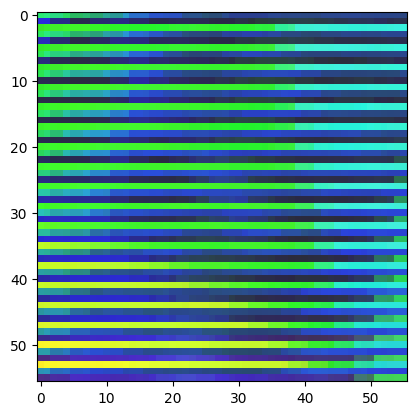

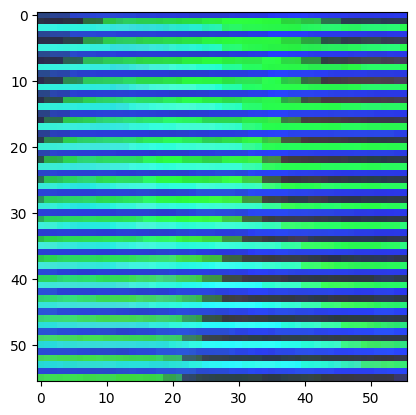

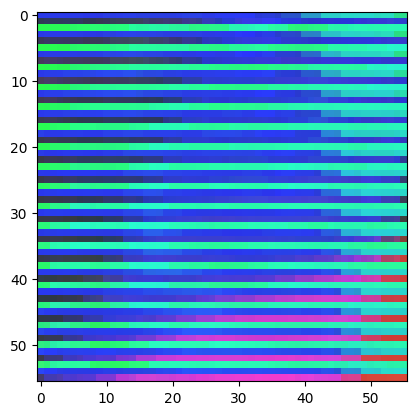

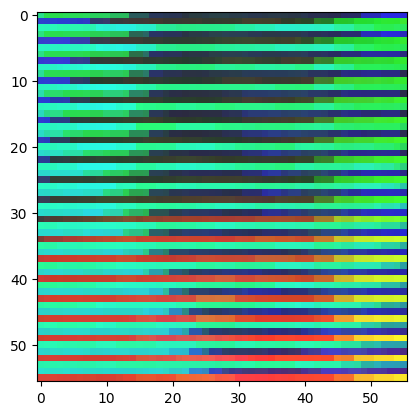

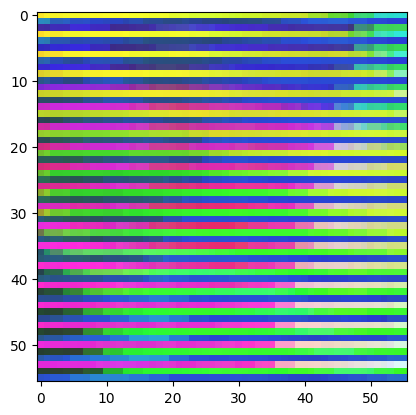

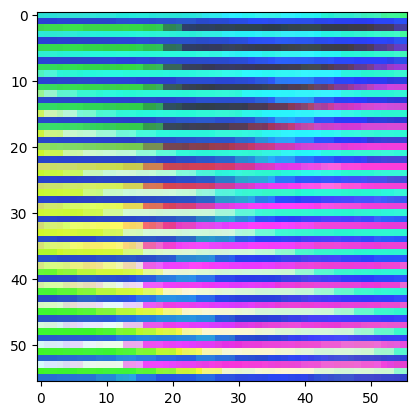

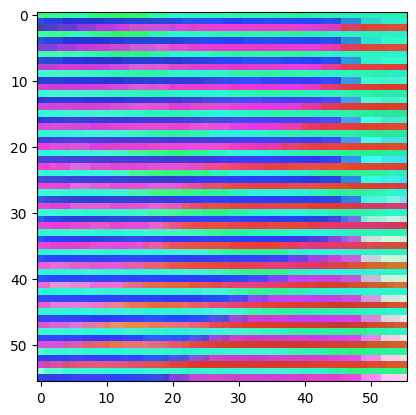

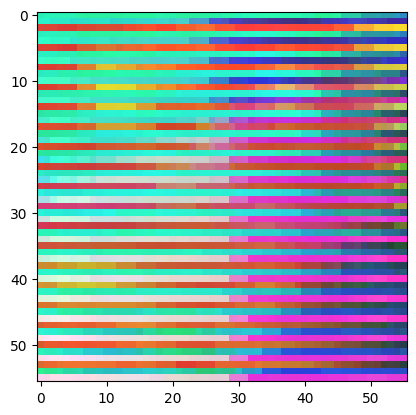

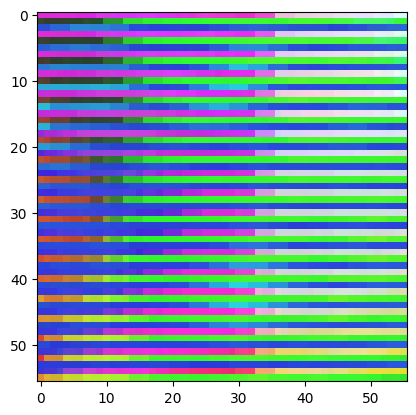

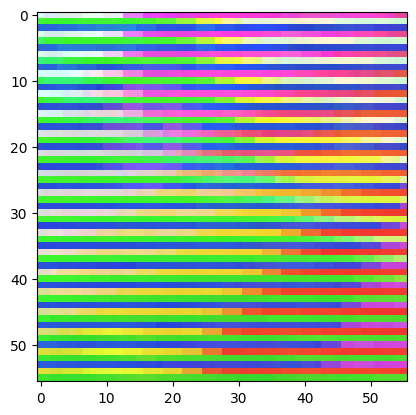

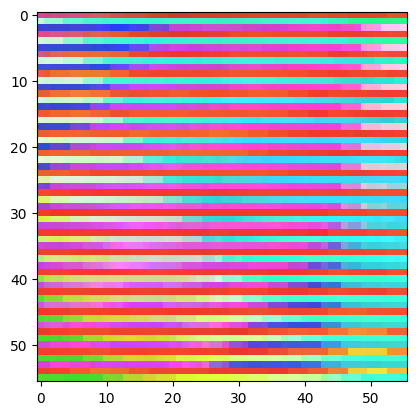

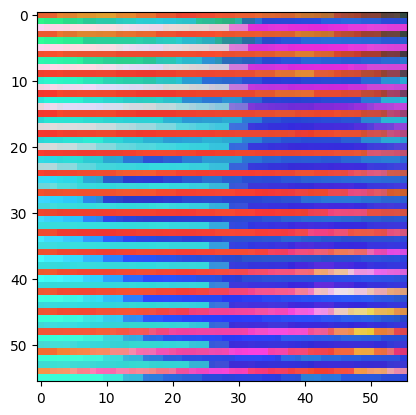

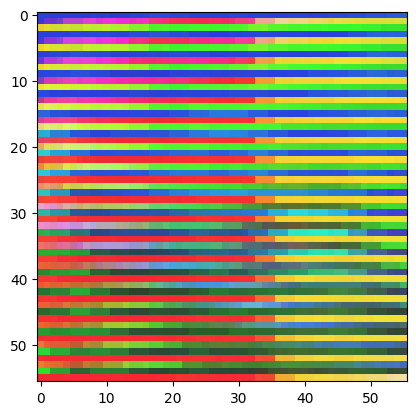

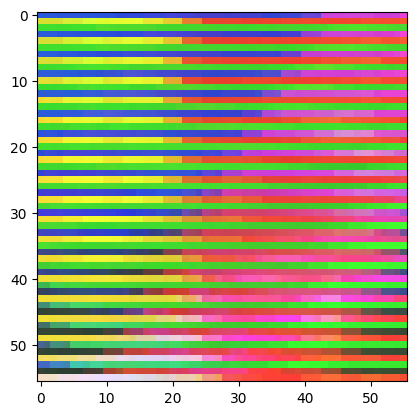

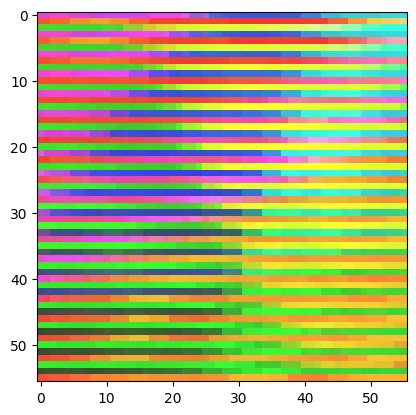

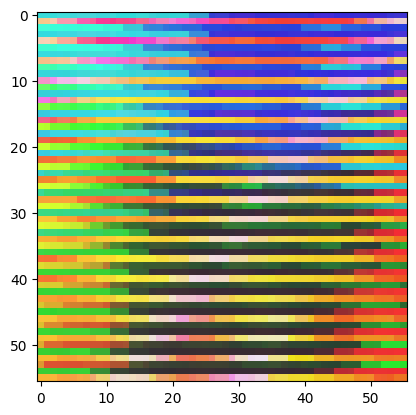

In [85]:
for i in range(16):
    p = p_out.squeeze()[i].view(56,56, 3)
    plt.imshow(p.detach().numpy())
    plt.show()